# Лабораторная работа №2
## Визуализация данных

**Выполнил:** Бушуев Никита  
**Вариант 1.** Набор данных: `drivers.csv`

---

**Цель работы:** осуществить разведочный анализ данных с помощью различных методов визуализации.

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BLUE, ORANGE, GREEN = '#4C72B0', '#DD8452', '#55A868'

df = pd.read_csv('drivers.csv', sep=';')
df.rename(columns={'CATEGORY*': 'CATEGORY', 'PURPOSEroute': 'PURPOSE_ROUTE'}, inplace=True)
df['START_DATE'] = pd.to_datetime(df['START_DATE'], format='mixed', dayfirst=False)
df['END_DATE'] = pd.to_datetime(df['END_DATE'], format='mixed', dayfirst=False)
df['DURATION'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60
df['CATEGORY'] = df['CATEGORY'].str.strip().str.title()
df['PURPOSE_ROUTE'] = df['PURPOSE_ROUTE'].str.strip().str.title().fillna('Не определена')
df['MONTH'] = df['START_DATE'].dt.month
df_dist = df[df['MILES'] > 500].copy()

print("Размер датасета:", df.shape)
print("Столбцы:", df.columns.tolist())
df[['DURATION','MILES','MONTH']].describe().round(2)

Размер датасета: (161, 9)
Столбцы: ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES', 'PURPOSE_ROUTE', 'DURATION', 'MONTH']


,DURATION,MILES,MONTH
count,161.00,161.00,161.00
mean,20.04,37766.52,6.68
std,21.72,16614.93,3.42
min,1.00,0.80,1.00
25%,9.00,44931.00,3.00
50%,15.00,45008.00,7.00
75%,22.00,45081.00,10.00
max,206.00,45177.00,12.00


## Гистограммы распределений

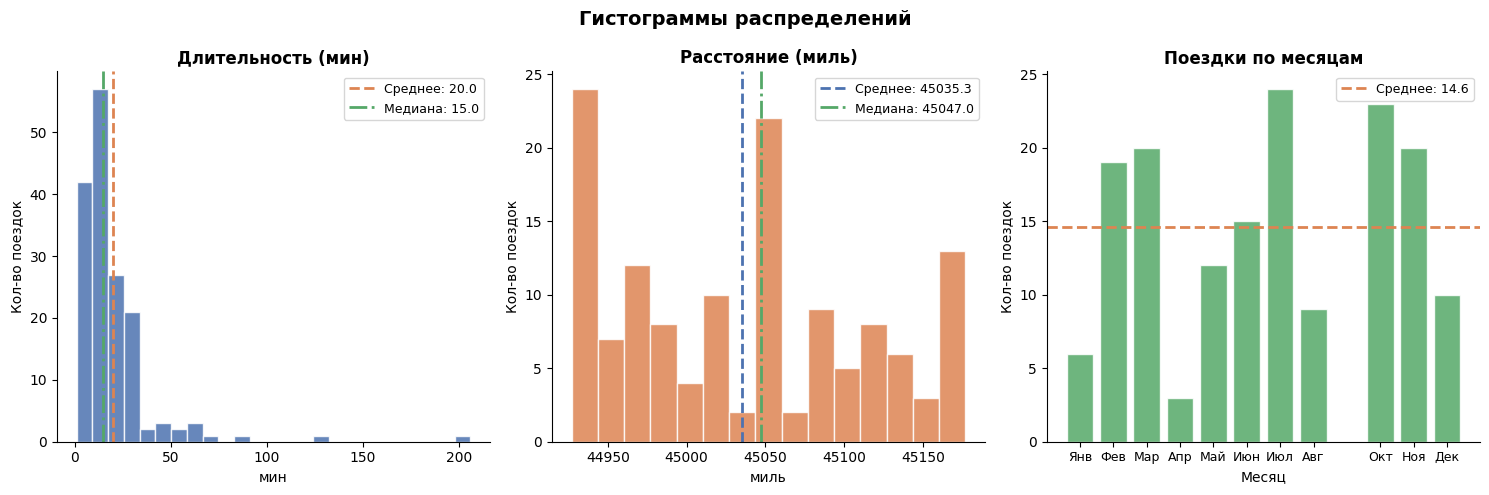

In [2]:
month_names_short = {1:'Янв',2:'Фев',3:'Мар',4:'Апр',5:'Май',6:'Июн',
                     7:'Июл',8:'Авг',9:'Сен',10:'Окт',11:'Ноя',12:'Дек'}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Гистограммы распределений', fontsize=14, fontweight='bold')

axes[0].hist(df['DURATION'], bins=25, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['DURATION'].mean(),   color=ORANGE, lw=2, ls='--', label=f'Среднее: {df["DURATION"].mean():.1f}')
axes[0].axvline(df['DURATION'].median(), color=GREEN,  lw=2, ls='-.', label=f'Медиана: {df["DURATION"].median():.1f}')
axes[0].set_title('Длительность (мин)', fontweight='bold')
axes[0].set_xlabel('мин'); axes[0].set_ylabel('Кол-во поездок'); axes[0].legend(fontsize=9)

axes[1].hist(df_dist['MILES'], bins=15, color=ORANGE, edgecolor='white', alpha=0.85)
axes[1].axvline(df_dist['MILES'].mean(),   color=BLUE,  lw=2, ls='--', label=f'Среднее: {df_dist["MILES"].mean():.1f}')
axes[1].axvline(df_dist['MILES'].median(), color=GREEN, lw=2, ls='-.', label=f'Медиана: {df_dist["MILES"].median():.1f}')
axes[1].set_title('Расстояние (миль)', fontweight='bold')
axes[1].set_xlabel('миль'); axes[1].set_ylabel('Кол-во поездок'); axes[1].legend(fontsize=9)

month_counts = df['MONTH'].value_counts().sort_index()
axes[2].bar(month_counts.index, month_counts.values, color=GREEN, edgecolor='white', alpha=0.85)
axes[2].axhline(month_counts.mean(), color=ORANGE, lw=2, ls='--', label=f'Среднее: {month_counts.mean():.1f}')
axes[2].set_xticks(month_counts.index)
axes[2].set_xticklabels([month_names_short[m] for m in month_counts.index], fontsize=9)
axes[2].set_title('Поездки по месяцам', fontweight='bold')
axes[2].set_xlabel('Месяц'); axes[2].set_ylabel('Кол-во поездок'); axes[2].legend(fontsize=9)

for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

**Распределение длительности поездок (DURATION)** - правостороннее: большинство поездок длятся 5-20 мин, среднее (20 мин) превышает медиану (15 мин), что указывает на наличие выбросов. **Показания одометра (MILES)** распределены в диапазоне 44 927-45 177 и близки к равномерному: среднее (45 035) практически совпадает с медианой (45 047), выбросов нет. **Активность неравномерна по месяцам:** пик - июль (24 поездки) и октябрь (23 поездки), минимум - апрель (3 поездки), сентябрь в данных полностью отсутствует.

## Диаграммы размаха до обработки выбросов

Две реализации: **matplotlib** (DURATION) и **seaborn** (MILES).

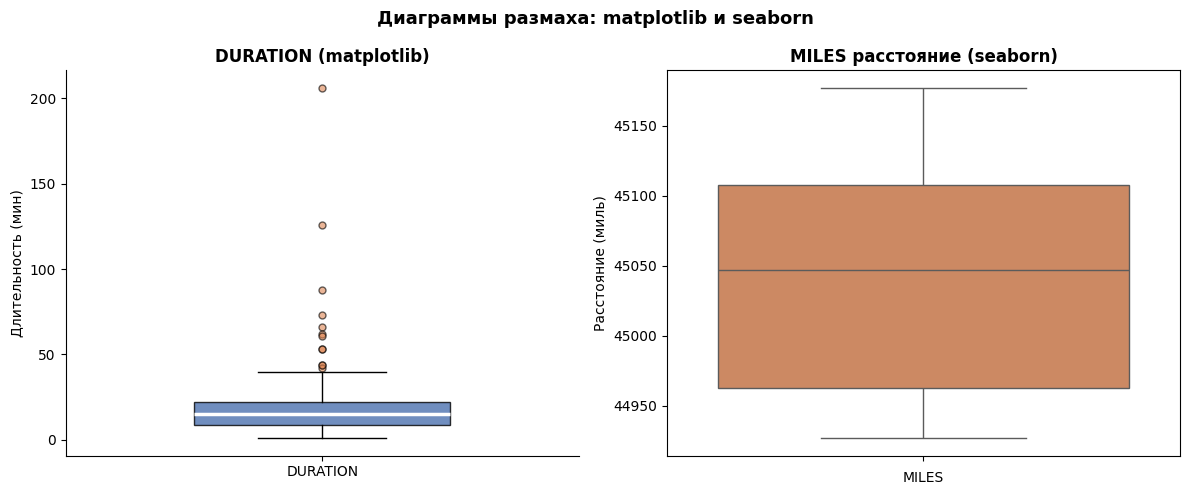

DURATION: Q1=9.0, Q3=22.0, IQR=13.0 | граница [-10.5; 41.5] | выбросов: 12
MILES: Q1=44963.0, Q3=45108.0, IQR=145.0 | граница [44745.5; 45325.5] | выбросов: 0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Диаграммы размаха: matplotlib и seaborn', fontsize=13, fontweight='bold')

bp = axes[0].boxplot(df['DURATION'].dropna(), patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', lw=2.5),
                     flierprops=dict(marker='o', markerfacecolor=ORANGE, markersize=5, alpha=0.6))
bp['boxes'][0].set_facecolor(BLUE); bp['boxes'][0].set_alpha(0.8)
axes[0].set_title('DURATION (matplotlib)', fontweight='bold')
axes[0].set_ylabel('Длительность (мин)'); axes[0].set_xticks([1]); axes[0].set_xticklabels(['DURATION'])
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

sns.boxplot(y=df_dist['MILES'], ax=axes[1], color=ORANGE)
axes[1].set_title('MILES расстояние (seaborn)', fontweight='bold')
axes[1].set_ylabel('Расстояние (миль)'); axes[1].set_xlabel('MILES')
plt.tight_layout(); plt.show()

for col, data in [('DURATION', df['DURATION']), ('MILES', df_dist['MILES'])]:
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((data < low) | (data > high)).sum()
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f} | граница [{low:.1f}; {high:.1f}] | выбросов: {outliers}")

Диаграммы размаха показали, что выбросы присутствуют только в столбце DURATION: 12 значений превышают верхнюю границу 1.5*IQR (41.5 мин), максимальное значение - 206 мин. **Для MILES выбросов не обнаружено** - все 135 значений находятся в пределах нормального диапазона [44 746; 45 326]. Графики построены с использованием разных библиотек: matplotlib (левый) и seaborn (правый).

## Обработка выбросов и графики после

Метод: замена значений за пределами 1.5*IQR на медиану.

DURATION: заменено 12 выбросов медианой 15 мин
DURATION до - после: mean 20.0 - 15.5, std 21.7 - 7.8


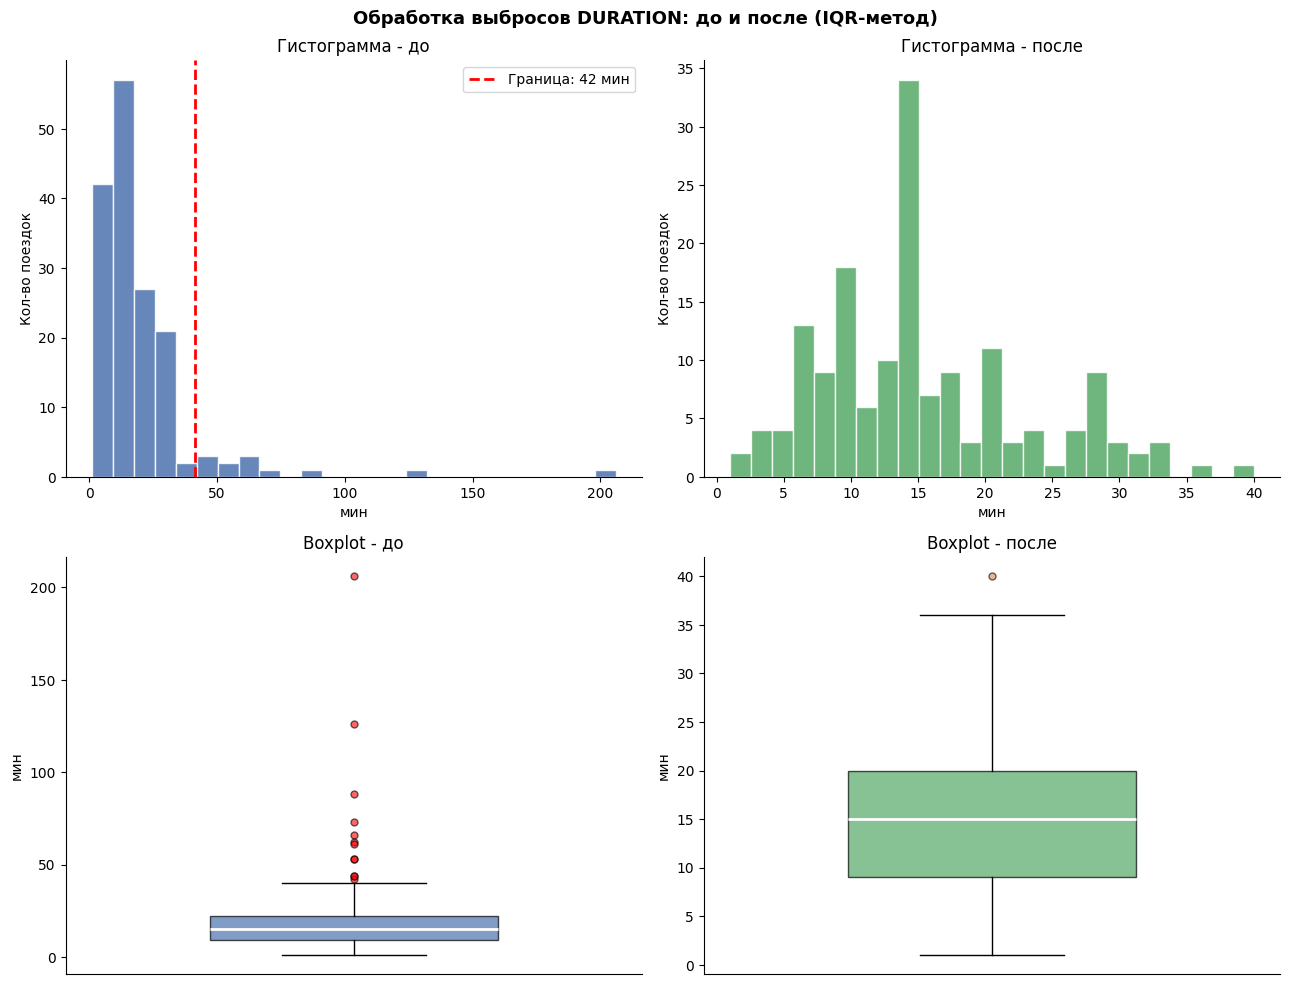

In [4]:
df_clean = df.copy()
Q1_d, Q3_d = df['DURATION'].quantile(0.25), df['DURATION'].quantile(0.75)
upper_d = Q3_d + 1.5 * (Q3_d - Q1_d)
median_d = df_clean['DURATION'].median()
mask_d = df_clean['DURATION'] > upper_d
df_clean.loc[mask_d, 'DURATION'] = median_d

df_dist_clean = df_dist.copy()

print(f"DURATION: заменено {mask_d.sum()} выбросов медианой {median_d:.0f} мин")
print(f"DURATION до - после: mean {df['DURATION'].mean():.1f} - {df_clean['DURATION'].mean():.1f}, "
      f"std {df['DURATION'].std():.1f} - {df_clean['DURATION'].std():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Обработка выбросов DURATION: до и после (IQR-метод)', fontsize=13, fontweight='bold')

axes[0,0].hist(df['DURATION'], bins=25, color=BLUE, edgecolor='white', alpha=0.85)
axes[0,0].axvline(upper_d, color='red', lw=2, ls='--', label=f'Граница: {upper_d:.0f} мин')
axes[0,0].set_title('Гистограмма - до'); axes[0,0].set_xlabel('мин')
axes[0,0].set_ylabel('Кол-во поездок'); axes[0,0].legend()

axes[0,1].hist(df_clean['DURATION'], bins=25, color=GREEN, edgecolor='white', alpha=0.85)
axes[0,1].set_title('Гистограмма - после'); axes[0,1].set_xlabel('мин')
axes[0,1].set_ylabel('Кол-во поездок')

for i, (data, color, title) in enumerate(zip(
    [df['DURATION'], df_clean['DURATION']], [BLUE, GREEN], ['Boxplot - до', 'Boxplot - после']
)):
    ax = axes[1, i]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
        medianprops=dict(color='white', lw=2),
        flierprops=dict(marker='o', markerfacecolor='red' if i==0 else ORANGE, markersize=5, alpha=0.6))
    bp['boxes'][0].set_facecolor(color); bp['boxes'][0].set_alpha(0.7)
    ax.set_title(title); ax.set_ylabel('мин'); ax.set_xticks([])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for ax in [axes[0,0], axes[0,1]]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

После обработки DURATION: среднее снизилось с 20.0 до 15.5 мин, стандартное отклонение - с 21.7 до 7.8 мин, максимальное значение - с 206 до 40 мин. Распределение стало более симметричным и компактным, на boxplot выбросы отсутствуют. **MILES обработки не требовал** - выбросов по методу IQR выявлено не было.

## 5. Boxplot длительности по категориям

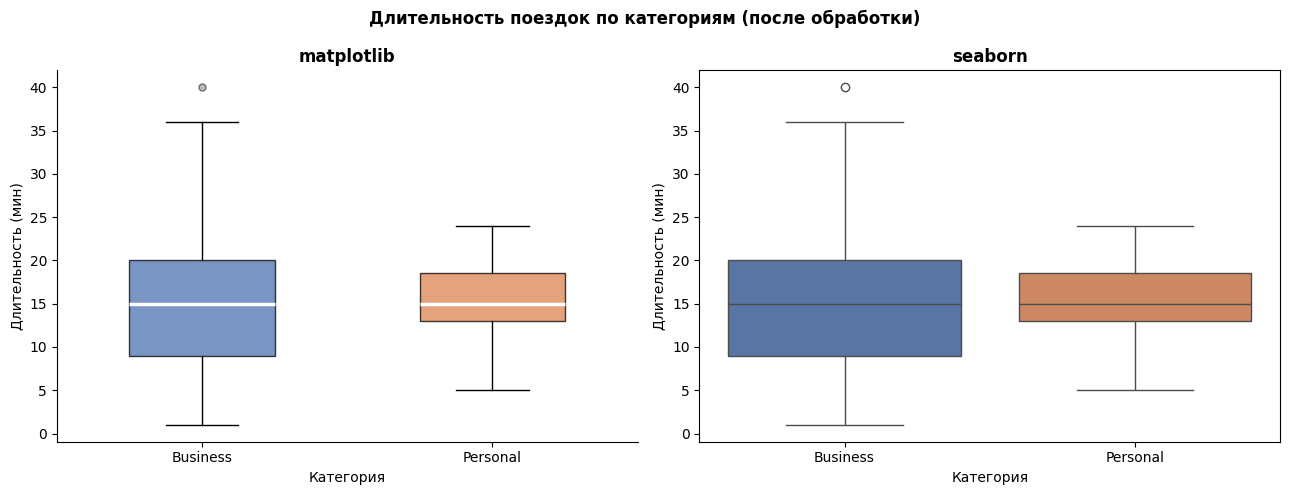

Business: n=150, медиана=15, Q1=9, Q3=20
Personal: n=11, медиана=15, Q1=13, Q3=18


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Длительность поездок по категориям (после обработки)', fontsize=12, fontweight='bold')

groups = [df_clean[df_clean['CATEGORY']==c]['DURATION'].values for c in ['Business','Personal']]
bp = axes[0].boxplot(groups, labels=['Business','Personal'], patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', lw=2.5),
                     flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5))
for patch, color in zip(bp['boxes'], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_title('matplotlib', fontweight='bold')
axes[0].set_xlabel('Категория'); axes[0].set_ylabel('Длительность (мин)')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

sns.boxplot(data=df_clean, x='CATEGORY', y='DURATION', ax=axes[1],
            palette={'Business': BLUE, 'Personal': ORANGE})
axes[1].set_title('seaborn', fontweight='bold')
axes[1].set_xlabel('Категория'); axes[1].set_ylabel('Длительность (мин)')
plt.tight_layout(); plt.show()

for cat in ['Business','Personal']:
    s = df_clean[df_clean['CATEGORY']==cat]['DURATION']
    print(f"{cat}: n={len(s)}, медиана={s.median():.0f}, Q1={s.quantile(0.25):.0f}, Q3={s.quantile(0.75):.0f}")

Медианная длительность Business и Personal поездок практически одинакова (~15 мин). Разброс (IQR) у Business-поездок несколько шире - это объясняется большим числом наблюдений (150 против 11) и разнообразием маршрутов. Статистически значимых различий между категориями по длительности поездок не обнаружено.

## 6. Матрица диаграмм рассеяния

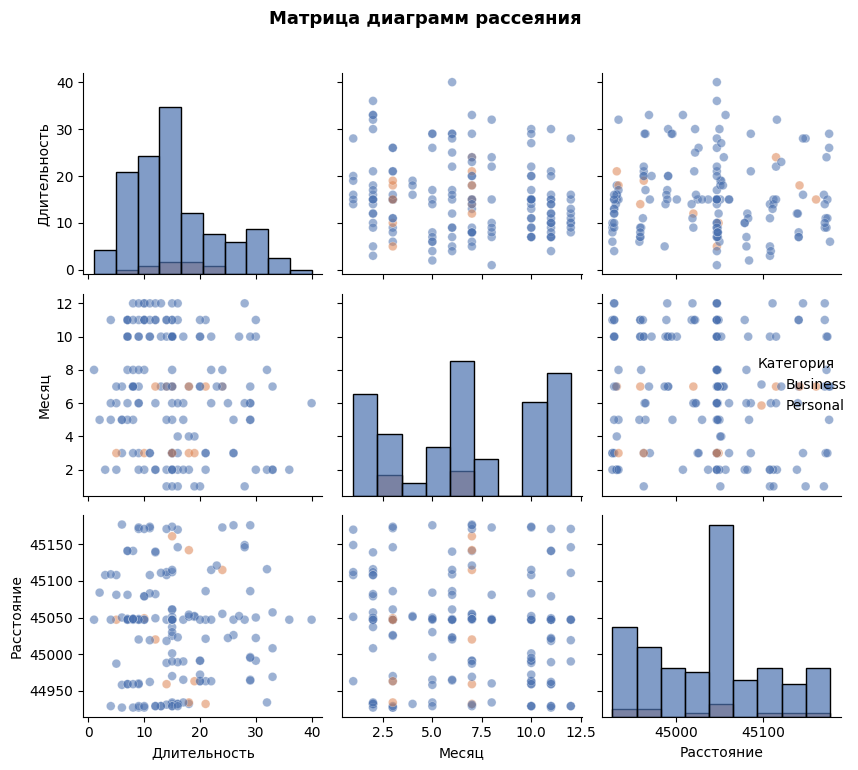

In [6]:
df_pair = df_clean[['DURATION','MONTH','CATEGORY']].copy()
df_pair['MILES'] = df['MILES'].where(df['MILES'] > 500, np.nan).fillna(
    df['MILES'].where(df['MILES'] > 500, np.nan).median())
df_pair.columns = ['Длительность', 'Месяц', 'Категория', 'Расстояние']

g = sns.pairplot(df_pair, hue='Категория',
                 palette={'Business': BLUE, 'Personal': ORANGE},
                 plot_kws=dict(alpha=0.55, s=40, edgecolor='white', linewidth=0.3),
                 diag_kws=dict(alpha=0.7), diag_kind='hist')
g.figure.suptitle('Матрица диаграмм рассеяния', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Матрица рассеяния не выявила выраженных линейных зависимостей. Пары Длительность-Расстояние и Длительность-Месяц показывают диффузное облако точек без тренда. Business-поездки (синие) охватывают весь диапазон значений одометра, Personal (оранжевые) сосредоточены в небольшой подобласти из-за малой выборки (11 записей). Диагональные гистограммы подтверждают правостороннее распределение DURATION и близкое к равномерному - MILES.

## 7. Тепловая карта корреляции

               Длительность  Месяц  Расстояние  Деловая (0/1)
Длительность          1.000 -0.160      -0.020         -0.003
Месяц                -0.160  1.000      -0.065          0.119
Расстояние           -0.020 -0.065       1.000          0.014
Деловая (0/1)        -0.003  0.119       0.014          1.000


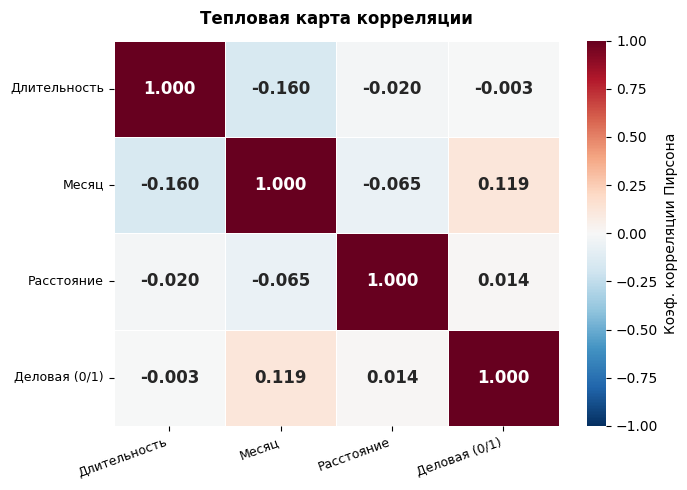

In [7]:
df_corr = df_clean[['DURATION','MONTH']].copy()
df_corr['MILES'] = df['MILES'].where(df['MILES'] > 500, np.nan).fillna(
    df['MILES'].where(df['MILES'] > 500, np.nan).median())
df_corr['IS_BUSINESS'] = (df_clean['CATEGORY'] == 'Business').astype(int)
df_corr.columns = ['Длительность', 'Месяц', 'Расстояние', 'Деловая (0/1)']

corr_matrix = df_corr.corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Коэф. корреляции Пирсона'})
ax.set_title('Тепловая карта корреляции', fontsize=12, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

**Интерпретация корреляций:**

| Пара переменных | r | Интерпретация |
|---|---|---|
| Длительность - Месяц | -0.160 | Слабая отрицательная |
| Длительность - Расстояние | -0.020 | Отсутствует |
| Длительность - Деловая | -0.003 | Отсутствует |
| Месяц - Расстояние | -0.065 | Отсутствует |
| Месяц - Деловая | 0.119 | Очень слабая |
| Расстояние - Деловая | 0.014 | Отсутствует |

Линейная взаимосвязь между переменными практически отсутствует (все |r| < 0.2).

Все коэффициенты корреляции Пирсона находятся в диапазоне |r| < 0.2, что соответствует слабой или нулевой линейной зависимости. Наиболее значимая связь - слабая отрицательная между Длительностью и Месяцем (r = -0.16): в более поздние месяцы года поездки незначительно короче. Столбец Расстояние (MILES) не коррелирует ни с одной переменной (|r| < 0.07). Категория «Деловая» также не связана с числовыми признаками. **Вывод:** линейная взаимосвязь между переменными датасета отсутствует.

## 8. Violin plot по целям маршрута

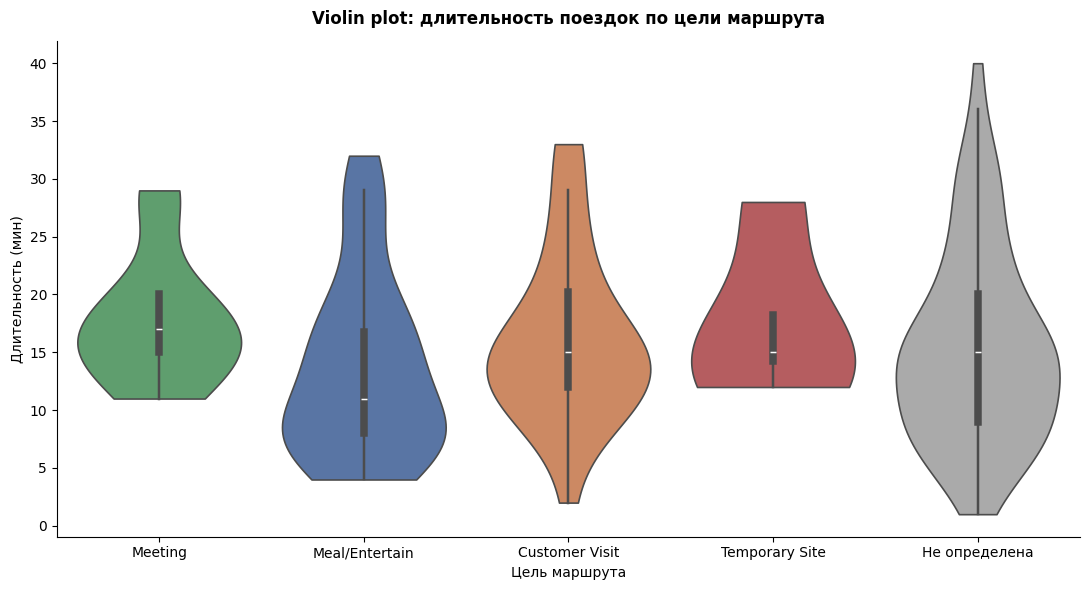

                median  mean  count
PURPOSE_ROUTE                      
Customer Visit    15.0  16.2     30
Meal/Entertain    11.0  13.6     36
Meeting           17.0  17.8     13
Temporary Site    15.0  17.5      4
Не определена     15.0  15.5     77


In [8]:
top_purposes = df_clean['PURPOSE_ROUTE'].value_counts().nlargest(5).index.tolist()
df_violin = df_clean[df_clean['PURPOSE_ROUTE'].isin(top_purposes)].copy()

palette_v = {
    'Не определена': '#AAAAAA', 'Meal/Entertain': BLUE,
    'Customer Visit': ORANGE, 'Meeting': GREEN, 'Temporary Site': '#C44E52',
}
fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(data=df_violin, x='PURPOSE_ROUTE', y='DURATION', ax=ax,
               palette=palette_v, inner='box', linewidth=1.2, cut=0)
ax.set_title('Violin plot: длительность поездок по цели маршрута', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Цель маршрута'); ax.set_ylabel('Длительность (мин)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(df_violin.groupby('PURPOSE_ROUTE')['DURATION'].agg(['median','mean','count']).round(1))

Violin plot визуализирует как медиану, так и форму распределения длительности поездок для каждой категории цели маршрута. Поездки на Meeting имеют медиану 17 мин, Customer Visit - 15 мин, Meal/Entertain - 11 мин. Категория «Не определена» обладает наиболее широкой «скрипкой» из-за большого числа наблюдений (77). В целом различия между категориями незначительны.

## Выводы

В ходе лабораторной работы выполнена визуализация данных датасета `drivers.csv` с использованием библиотек **matplotlib** и **seaborn**, в результате которой построено 7 типов визуализаций.
Гистограммы показали правостороннее распределение длительности поездок (DURATION), а также выраженную неравномерность активности по месяцам: пик приходится на июль и октябрь, провал - на апрель, сентябрь в данных отсутствует полностью. Показания одометра (MILES) распределены равномерно в диапазоне 44 927-45 177, среднее практически совпадает с медианой, выбросов не обнаружено. Методом IQR выявлены и обработаны выбросы только в столбце DURATION: 12 значений превысили верхнюю границу 41.5 мин при максимуме 206 мин; после замены на медиану стандартное отклонение снизилось почти в три раза - с 21.7 до 7.8 мин.
Сравнение категорий поездок Business и Personal по boxplot не выявило значимых различий - медианы совпадают и составляют около 15 мин. Матрица рассеяния подтвердила отсутствие трендов между числовыми переменными. Тепловая карта корреляции установила, что все коэффициенты Пирсона не превышают |r| = 0.2, то есть линейные зависимости в датасете отсутствуют; наиболее заметная из них - слабая отрицательная между длительностью и месяцем года (r = -0.16). Violin plot выявил незначительную разницу медиан по целям маршрута: у категории Meeting медиана составляет 17 мин, у Meal/Entertain - 11 мин.
Таким образом, датасет описывает корпоративные поездки без статистически значимых линейных зависимостей между признаками, а основная ценность проведённой визуализации состоит в обнаружении выбросов в столбце DURATION и неравномерности распределения активности по времени.